In [1]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [2]:
tile_dir = Path("../data/bronze/ashanti-2021-jan/tile_0")

# Bands to load
band_to_name = {
    "B02": "blue",
    "B03": "green",
    "B04": "red",
    "B05": "rededge",
    "B08": "nir",
    "B12": "swir22",
}

# Load each band and assign a name
bands = {}
for band, name in band_to_name.items():
    da = rioxarray.open_rasterio(tile_dir / f"{band}.tif", masked=True)
    da = da.squeeze("band", drop=True)  # drop the redundant band dim (it's 1)
    da = da.astype("float16")
    da /= 255
    bands[name] = da

# Combine into a Dataset — all bands aligned on (y, x)
ds = xr.Dataset(bands)

aux_names = ["cloud_confidence", "scene_classification", "valid_observations", "validation_source_index"]
for aux in aux_names:
    da = rioxarray.open_rasterio(tile_dir / f"{aux}.tif", masked=True)
    ds[aux] = da.squeeze("band", drop=True)

print(ds)

<xarray.Dataset> Size: 13GB
Dimensions:                  (x: 24569, y: 19612)
Coordinates:
  * x                        (x) float64 197kB -2.452 -2.451 ... -0.2377 -0.2376
  * y                        (y) float64 157kB 7.622 7.622 7.622 ... 5.855 5.855
    spatial_ref              int64 8B 0
Data variables:
    blue                     (y, x) float16 964MB nan nan nan ... nan nan nan
    green                    (y, x) float16 964MB nan nan nan ... nan nan nan
    red                      (y, x) float16 964MB nan nan nan ... nan nan nan
    rededge                  (y, x) float16 964MB nan nan nan ... nan nan nan
    nir                      (y, x) float16 964MB nan nan nan ... nan nan nan
    swir22                   (y, x) float16 964MB nan nan nan ... nan nan nan
    cloud_confidence         (y, x) float32 2GB ...
    scene_classification     (y, x) float32 2GB ...
    valid_observations       (y, x) float32 2GB ...
    validation_source_index  (y, x) float32 2GB ...


EPSG:4326


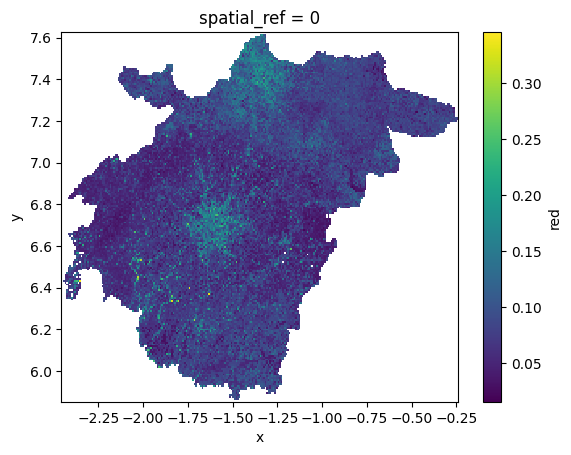

In [3]:
# Check CRS and resolution
print(ds.rio.crs)

# Downsample & plot
step = 100
ds_small = ds.isel(y=slice(None, None, step), x=slice(None, None, step))
ds_small.red.plot()

In [4]:
# Get the bounding box from your existing dataset
bounds = ds.rio.bounds()  # (left, bottom, right, top)

# Open the large raster and clip to the bounding box
big = rioxarray.open_rasterio("../data/bronze/cocoa_map.tif", masked=True)
print(big.rio.crs)
clipped = big.rio.clip_box(*bounds)
clipped = clipped.astype("float16")

EPSG:4326


In [5]:
clipped_matched = clipped.rio.reproject_match(ds)
ds["ethz_map"] = clipped_matched.squeeze("band", drop=True)
print(ds)

<xarray.Dataset> Size: 14GB
Dimensions:                  (x: 24569, y: 19612)
Coordinates:
  * x                        (x) float64 197kB -2.452 -2.451 ... -0.2377 -0.2376
  * y                        (y) float64 157kB 7.622 7.622 7.622 ... 5.855 5.855
    spatial_ref              int64 8B 0
Data variables:
    blue                     (y, x) float16 964MB nan nan nan ... nan nan nan
    green                    (y, x) float16 964MB nan nan nan ... nan nan nan
    red                      (y, x) float16 964MB nan nan nan ... nan nan nan
    rededge                  (y, x) float16 964MB nan nan nan ... nan nan nan
    nir                      (y, x) float16 964MB nan nan nan ... nan nan nan
    swir22                   (y, x) float16 964MB nan nan nan ... nan nan nan
    cloud_confidence         (y, x) float32 2GB ...
    scene_classification     (y, x) float32 2GB ...
    valid_observations       (y, x) float32 2GB ...
    validation_source_index  (y, x) float32 2GB ...
    ethz_map   

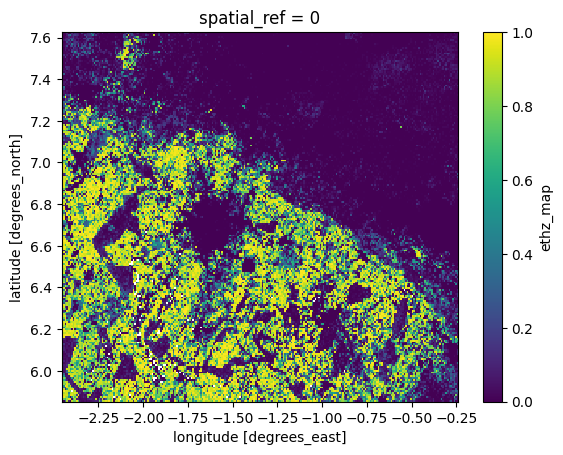

In [6]:
# Downsample and plot
step = 100
ds_small = ds.isel(y=slice(None, None, step), x=slice(None, None, step))
ds_small.ethz_map.plot()

In [12]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.ndimage import median_filter

# Define your columns and variables
grid_vars = ["red", "green", "blue", "rededge", "nir", "swir22", "scene_classification"]
band_names = list(band_to_name.values())
cols = band_names + aux_names + ["ethz_map"]

chunk_size = 500
n_chunks = (ds.sizes["y"] + chunk_size - 1) // chunk_size

chunks = []

for i in tqdm(range(0, ds.sizes["y"], chunk_size), total=n_chunks, desc="Processing chunks"):
    
    # 1. Slice chunk with 1-pixel buffer (same as before)
    start_y = max(0, i - 1)
    end_y = min(ds.sizes["y"], i + chunk_size + 1)
    chunk_ds = ds[cols].isel(y=slice(start_y, end_y))
    
    # Identify indices to strip the buffer later
    valid_start = 0 if i == 0 else 1
    valid_end = None if (i + chunk_size >= ds.sizes["y"]) else -1
    
    # 2. Extract coordinates and create a flat meshgrid
    valid_y_coords = chunk_ds.y.values[valid_start:valid_end]
    valid_x_coords = chunk_ds.x.values
    X, Y = np.meshgrid(valid_x_coords, valid_y_coords)
    
    # We will build a dictionary of 1D NumPy arrays to feed directly into Pandas
    chunk_data = {
        "lon": X.ravel(),
        "lat": Y.ravel()
    }
    
    # Track NaNs to drop empty rows efficiently later
    nan_mask = np.ones(chunk_data["lon"].shape, dtype=bool)
    
    # 3. Process variables purely in NumPy/SciPy
    for var in cols:
        # Extract underlying raw NumPy array
        arr = chunk_ds[var].values 
        
        # If it needs a median filter, use SciPy
        if var in grid_vars:
            # SciPy's median_filter doesn't support float16
            # We upcast to float32 for the calculation, then cast back to the original dtype
            compute_arr = arr.astype(np.float32) if arr.dtype == np.float16 else arr
            
            arr_filtered = median_filter(compute_arr, size=3, mode='nearest')
            
            # Cast back to float16 to preserve your RAM!
            arr_filtered = arr_filtered.astype(arr.dtype)
            
            # Trim the buffer rows, flatten, and save
            core_filtered = arr_filtered[valid_start:valid_end, :]
            chunk_data[f"{var}_3x3_median"] = core_filtered.ravel()
        
        # Trim buffer for the original variable, flatten, and save
        core_original = arr[valid_start:valid_end, :]
        chunk_data[var] = core_original.ravel()
        
        # If this variable is a band, update our NaN tracking mask
        if var in band_names:
            nan_mask &= np.isnan(chunk_data[var])
            
    # 4. Filter out rows where ALL band variables are NaN
    keep_mask = ~nan_mask
    
    # Apply the mask to all columns in our dictionary
    filtered_data = {k: v[keep_mask] for k, v in chunk_data.items()}
    
    # 5. Convert directly to DataFrame (extremely fast without MultiIndex overhead)
    chunks.append(pd.DataFrame(filtered_data))

# Concatenate all chunks
df = pd.concat(chunks, ignore_index=True)

Processing chunks: 100%|███████████████████████████████████████████████████████████████████████████| 40/40 [03:01<00:00,  4.54s/it]


In [13]:
df = df.sample(100_000)

In [15]:
df = df.dropna(subset=('ethz_map'))

In [16]:
df.to_pickle('ashanti_df.pkl')

# Train models

In [17]:
df = pd.read_pickle('ashanti_df.pkl')

In [18]:
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, f1_score, precision_score, recall_score

X = df.drop(columns=["ethz_map"])
y = df["ethz_map"]

dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(X, y)
y_pred = dummy_regr.predict(X)

print(f"Dummy Constant Value: {dummy_regr.constant_[0][0]:.4f}")
print(f"Baseline MSE: {mean_squared_error(y, y_pred):.4f}")
print(f"Baseline MAE: {mean_absolute_error(y, y_pred):.4f}")
print('---'*3)
y_pred = y_pred > 0.5
y = y > 0.65
print(f"Baseline Macro F1: {f1_score(y, y_pred, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Precision: {precision_score(y, y_pred, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Recall: {recall_score(y, y_pred, average='macro', zero_division=0):.4f}")

Dummy Constant Value: 0.3083
Baseline MSE: 0.1467
Baseline MAE: 0.3447
---------
Baseline Macro F1: 0.4221
Baseline Macro Precision: 0.3651
Baseline Macro Recall: 0.5000


/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:578: RuntimeWarning: overflow encountered in cast
  scl = avg_as_array.dtype.type(a.size / avg_as_array.size)
/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:578: RuntimeWarning: overflow encountered in cast
  scl = avg_as_array.dtype.type(a.size / avg_as_array.size)
/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:578: RuntimeWarning: overflow encountered in cast
  scl = avg_as_array.dtype.type(a.size / avg_as_array.size)


In [19]:
# Build X,y
df["ethz_class"] = (df["ethz_map"] >= 0.65).astype(int)
X = df.drop(columns=["ethz_class", "ethz_map"], errors="ignore")
y = df["ethz_class"]

# Initialize and fit the Dummy Classifier
dummy_clf = DummyClassifier(strategy="stratified")
dummy_clf.fit(X, y)
y_pred = dummy_clf.predict(X)

# Evaluate the baseline
print(f"Baseline Macro F1: {f1_score(y, y_pred, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Precision: {precision_score(y, y_pred, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Recall: {recall_score(y, y_pred, average='macro', zero_division=0):.4f}")
print("- Negative (0)")
print(f"- F1: {f1_score(y, y_pred, pos_label=0, zero_division=0):.4f}")
print(f"-- Precision: {precision_score(y, y_pred, pos_label=0, zero_division=0):.4f}")
print(f"-- Recall: {recall_score(y, y_pred, pos_label=0, zero_division=0):.4f}")
print("- Positive (1)")
print(f"- F1: {f1_score(y, y_pred, pos_label=1, zero_division=0):.4f}")
print(f"-- Precision: {precision_score(y, y_pred, pos_label=1, zero_division=0):.4f}")
print(f"-- Recall: {recall_score(y, y_pred, pos_label=1, zero_division=0):.4f}")

Baseline Macro F1: 0.4976
Baseline Macro Precision: 0.4975
Baseline Macro Recall: 0.4976
- Negative (0)
- F1: 0.7302
-- Precision: 0.7289
-- Recall: 0.7316
- Positive (1)
- F1: 0.2649
-- Precision: 0.2662
-- Recall: 0.2636


In [20]:
# Should I keep only the points with >x observation ? .valid_observation
# Should I only consider using an elevation map ? (DEM)
# Should I drop high cloud ? Thin cirrus ? Not vegetated ? Unclassified ? Water ? 
df.head(1)

/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,lon,lat,blue_3x3_median,blue,green_3x3_median,green,red_3x3_median,red,rededge_3x3_median,rededge,...,nir,swir22_3x3_median,swir22,cloud_confidence,scene_classification_3x3_median,scene_classification,valid_observations,validation_source_index,ethz_map,ethz_class
44503700,-0.275169,7.237079,0.09021,0.09021,0.098022,0.094116,0.09021,0.086304,0.113708,0.10199,...,0.133301,0.094116,0.094116,0.0,5.0,5.0,8.0,80.0,0.016479,0


# Prep hyperparam optimization

In [21]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score

def optuna_objective_factory(X, y):
    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 15),
            'num_leaves': trial.suggest_int('num_leaves', 10, 256),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'n_jobs': -1,
            'verbose': -1,
            'random_state': 42
        }
        
        
        # Use cross-validation to evaluate the parameters on the training data
        model = lgb.LGBMClassifier(**param)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(model, X, y, cv=cv, scoring='f1_macro', n_jobs=1)
        
        return scores.mean()

    return objective

# Train LGBM baseline

In [22]:
# Split
features = ['blue', "green", "red", "rededge", "nir", "swir22"]
X = df[features]
y = df["ethz_map"] > 0.65

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y > 0.65)
X_train.head(2)

/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,blue,green,red,rededge,nir,swir22
46261182,0.047058,0.070618,0.047058,0.086304,0.207886,0.070618
142561655,0.054901,0.074524,0.039215,0.090210,0.270508,0.066650


In [23]:
def train_test_lgbm(X_train, y_train, X_test, y_test, n_trials=3):
    print("Starting Optuna hyperparameter optimization...")
    study = optuna.create_study(direction="maximize") 
    study.optimize(optuna_objective_factory(X_train, y_train), n_trials=n_trials, show_progress_bar=True)
    
    # Build final model
    final_model = lgb.LGBMClassifier(**study.best_params)
    final_model.fit(X_train, y_train)
    
    yhat_train_pred = final_model.predict(X_train)
    yhat_test_pred = final_model.predict(X_test)
    
    print("\n--- OPTIMIZED MODEL EVALUATION ---")
    print("TRAIN")
    print(f"- Macro F1: {f1_score(y_train, yhat_train_pred, average='macro', zero_division=0):.4f}")
    print(f"- Macro Precision: {precision_score(y_train, yhat_train_pred, average='macro', zero_division=0):.4f}")
    print(f"- Macro Recall: {recall_score(y_train, yhat_train_pred, average='macro', zero_division=0):.4f}")
    
    print("\nTEST")
    print(f"- Macro F1: {f1_score(y_test, yhat_test_pred, average='macro', zero_division=0):.4f}")
    print(f"- Macro Precision: {precision_score(y_test, yhat_test_pred, average='macro', zero_division=0):.4f}")
    print(f"- Macro Recall: {recall_score(y_test, yhat_test_pred, average='macro', zero_division=0):.4f}")

    return yhat_train_pred, yhat_test_pred

train_test_lgbm(X_train, y_train, X_test, y_test);

[I 2026-06-11 17:15:41,651] A new study created in memory with name: no-name-ee076393-abb0-4efb-9d0f-6208732358ba


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-11 17:15:49,488] Trial 0 finished with value: 0.7591342814493205 and parameters: {'n_estimators': 213, 'learning_rate': 0.0315698390761115, 'max_depth': 9, 'num_leaves': 106, 'subsample': 0.7020989542161723, 'colsample_bytree': 0.530734401299412, 'min_child_samples': 10}. Best is trial 0 with value: 0.7591342814493205.
[I 2026-06-11 17:16:00,014] Trial 1 finished with value: 0.7602350092745418 and parameters: {'n_estimators': 374, 'learning_rate': 0.17786817014294073, 'max_depth': 8, 'num_leaves': 203, 'subsample': 0.9988263581298941, 'colsample_bytree': 0.623166138337594, 'min_child_samples': 60}. Best is trial 1 with value: 0.7602350092745418.
[I 2026-06-11 17:16:23,390] Trial 2 finished with value: 0.7605945623425628 and parameters: {'n_estimators': 396, 'learning_rate': 0.07387126601218516, 'max_depth': 14, 'num_leaves': 168, 'subsample': 0.9018650842954801, 'colsample_bytree': 0.7835766027019344, 'min_child_samples': 42}. Best is trial 2 with value: 0.7605945623425628.


# Consider the SCL

In [24]:
# The SCL flags a lot of px as cloud and whatnot, but not vegetation
df['scene_classification'] = df.scene_classification.map({
    0: 'NO_DATA',
    1: 'DEFECTIVE_PX',
    2: 'TOPO_SHADOW',
    3: 'CLOUD_SHADOW',
    4: 'VEGETATION',
    5: 'NOT_VEGETATED',
    6: 'WATER',
    7: 'UNCLASSIFIED',
    8: 'CLOUD_MED_PROB',
    9: 'CLOUD_HIGH_PROB',
    10: 'THIN_CIRRUS',
    11: 'SNOW_OR_ICE',
})
df.head(1)

/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,lon,lat,blue_3x3_median,blue,green_3x3_median,green,red_3x3_median,red,rededge_3x3_median,rededge,...,nir,swir22_3x3_median,swir22,cloud_confidence,scene_classification_3x3_median,scene_classification,valid_observations,validation_source_index,ethz_map,ethz_class
44503700,-0.275169,7.237079,0.09021,0.09021,0.098022,0.094116,0.09021,0.086304,0.113708,0.10199,...,0.133301,0.094116,0.094116,0.0,5.0,NOT_VEGETATED,8.0,80.0,0.016479,0


<Axes: xlabel='scene_classification', ylabel='Proportion'>

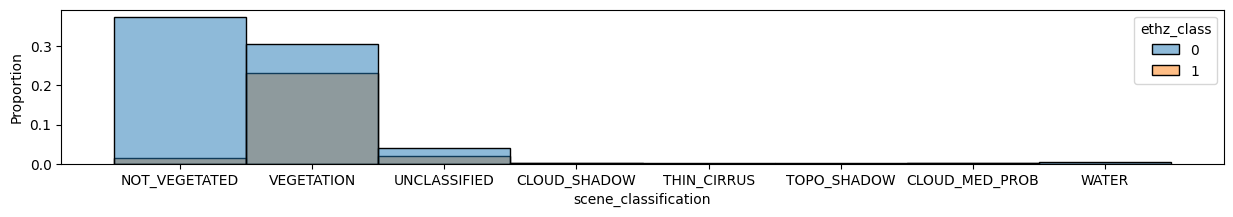

In [25]:
# There are points that are not vegetated, BUT considered as "cocoa" 
plt.figure(figsize=(15,2))
sns.histplot(x="scene_classification", hue='ethz_class', data=df, stat="proportion")

In [26]:
# Ditch defective points
mask = df.scene_classification == "NO_DATA"
mask |= df.scene_classification == "DEFECTIVE_PX"
print(f"Discarded {mask.sum()}/{len(df)} ({mask.sum() / len(df) * 100:.2f}%) points")
df = df[~mask]
df.head(1)

Discarded 0/99759 (0.00%) points


/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,lon,lat,blue_3x3_median,blue,green_3x3_median,green,red_3x3_median,red,rededge_3x3_median,rededge,...,nir,swir22_3x3_median,swir22,cloud_confidence,scene_classification_3x3_median,scene_classification,valid_observations,validation_source_index,ethz_map,ethz_class
44503700,-0.275169,7.237079,0.09021,0.09021,0.098022,0.094116,0.09021,0.086304,0.113708,0.10199,...,0.133301,0.094116,0.094116,0.0,5.0,NOT_VEGETATED,8.0,80.0,0.016479,0


In [27]:
# Ditch clouds
mask = df.scene_classification == "CLOUD_MED_PROB"
mask |= df.scene_classification == "CLOUD_HIGH_PROB"
mask |= df.scene_classification == "THIN_CIRRUS"
print(f"Discarded {mask.sum()}/{len(df)} ({mask.sum() / len(df) * 100:.2f}%) points")
df = df[~mask]
df.head(1)

Discarded 286/99759 (0.29%) points


/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,lon,lat,blue_3x3_median,blue,green_3x3_median,green,red_3x3_median,red,rededge_3x3_median,rededge,...,nir,swir22_3x3_median,swir22,cloud_confidence,scene_classification_3x3_median,scene_classification,valid_observations,validation_source_index,ethz_map,ethz_class
44503700,-0.275169,7.237079,0.09021,0.09021,0.098022,0.094116,0.09021,0.086304,0.113708,0.10199,...,0.133301,0.094116,0.094116,0.0,5.0,NOT_VEGETATED,8.0,80.0,0.016479,0


In [28]:
# Split
features = ['blue', "green", "red", "rededge", "nir", "swir22"]
X = df[features]
y = df["ethz_map"] > 0.65

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y > 0.65)

train_test_lgbm(X_train, y_train, X_test, y_test);

[I 2026-06-11 17:16:28,082] A new study created in memory with name: no-name-b9484028-66b1-46f7-869b-c434b0edeaeb


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-11 17:16:31,989] Trial 0 finished with value: 0.7654618420272667 and parameters: {'n_estimators': 490, 'learning_rate': 0.11942675187972474, 'max_depth': 14, 'num_leaves': 12, 'subsample': 0.8981968778281988, 'colsample_bytree': 0.6553827636508085, 'min_child_samples': 16}. Best is trial 0 with value: 0.7654618420272667.
[I 2026-06-11 17:16:37,751] Trial 1 finished with value: 0.765039830088563 and parameters: {'n_estimators': 334, 'learning_rate': 0.17210842685375063, 'max_depth': 6, 'num_leaves': 87, 'subsample': 0.7463254221421639, 'colsample_bytree': 0.9537804366208459, 'min_child_samples': 53}. Best is trial 0 with value: 0.7654618420272667.
[I 2026-06-11 17:16:40,139] Trial 2 finished with value: 0.762407567774011 and parameters: {'n_estimators': 291, 'learning_rate': 0.0961652982026244, 'max_depth': 3, 'num_leaves': 23, 'subsample': 0.8878865682364369, 'colsample_bytree': 0.8620651572673621, 'min_child_samples': 86}. Best is trial 0 with value: 0.7654618420272667.

--

# Add TCI

In [29]:
# Add TCI
df["tci"] = 1.2 * (df["rededge"] - df["green"]) - 1.5 * (df["red"] - df["green"]) * np.sqrt(df["rededge"] / df["red"])

In [30]:
# Split
features = ['blue', "green", "red", "rededge", "nir", "swir22", "tci"]
X = df[features]
y = df["ethz_map"] > 0.65

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y > 0.65)
X_train.head(2)

/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,blue,green,red,rededge,nir,swir22,tci
233723912,0.098022,0.109802,0.074524,0.113708,0.305908,0.062744,0.070068
84510605,0.043152,0.070618,0.035309,0.086304,0.305908,0.062744,0.101685


In [31]:
train_test_lgbm(X_train, y_train, X_test, y_test);

[I 2026-06-11 17:16:41,491] A new study created in memory with name: no-name-e4083c6d-2d3c-4f44-a134-755346b7d9e1


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-11 17:16:51,494] Trial 0 finished with value: 0.7656707043788585 and parameters: {'n_estimators': 351, 'learning_rate': 0.0900627779055731, 'max_depth': 12, 'num_leaves': 62, 'subsample': 0.9121968118518671, 'colsample_bytree': 0.7517142175213969, 'min_child_samples': 60}. Best is trial 0 with value: 0.7656707043788585.
[I 2026-06-11 17:17:16,539] Trial 1 finished with value: 0.7525961277607234 and parameters: {'n_estimators': 478, 'learning_rate': 0.17738977446457196, 'max_depth': 13, 'num_leaves': 184, 'subsample': 0.6605483694124674, 'colsample_bytree': 0.8344898989747973, 'min_child_samples': 96}. Best is trial 0 with value: 0.7656707043788585.
[I 2026-06-11 17:17:31,452] Trial 2 finished with value: 0.7665175669596356 and parameters: {'n_estimators': 321, 'learning_rate': 0.019276722120520357, 'max_depth': 15, 'num_leaves': 91, 'subsample': 0.945133723072126, 'colsample_bytree': 0.8307336968124603, 'min_child_samples': 71}. Best is trial 2 with value: 0.7665175669596356

# Add NDVI

In [32]:
# Add NDVI
df["ndvi"] = (df["nir"] - df["red"]) / (df["nir"] + df["red"])
df.head(1)

/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,lon,lat,blue_3x3_median,blue,green_3x3_median,green,red_3x3_median,red,rededge_3x3_median,rededge,...,swir22,cloud_confidence,scene_classification_3x3_median,scene_classification,valid_observations,validation_source_index,ethz_map,ethz_class,tci,ndvi
44503700,-0.275169,7.237079,0.09021,0.09021,0.098022,0.094116,0.09021,0.086304,0.113708,0.10199,...,0.094116,0.0,5.0,NOT_VEGETATED,8.0,80.0,0.016479,0,0.022186,0.213989


In [33]:
# Split
features = ['blue', "green", "red", "rededge", "nir", "swir22", "tci", "ndvi"]
X = df[features]
y = df["ethz_map"] > 0.65

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y > 0.65)
X_train.head(2)

/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,blue,green,red,rededge,nir,swir22,tci,ndvi
233723912,0.098022,0.109802,0.074524,0.113708,0.305908,0.062744,0.070068,0.608398
84510605,0.043152,0.070618,0.035309,0.086304,0.305908,0.062744,0.101685,0.792480


In [34]:
yhat_train, yhat_test = train_test_lgbm(X_train, y_train, X_test, y_test);

[I 2026-06-11 17:17:34,504] A new study created in memory with name: no-name-90c7857d-19c7-45ac-a2c5-274693450901


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-11 17:17:40,282] Trial 0 finished with value: 0.7670814797494645 and parameters: {'n_estimators': 437, 'learning_rate': 0.07620453004651612, 'max_depth': 5, 'num_leaves': 191, 'subsample': 0.7325395818846087, 'colsample_bytree': 0.7178419042475519, 'min_child_samples': 76}. Best is trial 0 with value: 0.7670814797494645.
[I 2026-06-11 17:17:46,494] Trial 1 finished with value: 0.7625356827619474 and parameters: {'n_estimators': 401, 'learning_rate': 0.01894142619755955, 'max_depth': 5, 'num_leaves': 45, 'subsample': 0.6184229831147756, 'colsample_bytree': 0.6625173998504782, 'min_child_samples': 88}. Best is trial 0 with value: 0.7670814797494645.
[I 2026-06-11 17:17:48,741] Trial 2 finished with value: 0.6991074280581769 and parameters: {'n_estimators': 118, 'learning_rate': 0.010343578867416403, 'max_depth': 5, 'num_leaves': 194, 'subsample': 0.6952435735279494, 'colsample_bytree': 0.8873421662847409, 'min_child_samples': 14}. Best is trial 0 with value: 0.7670814797494645

# Add GNDVI, NDWI

In [35]:
# Add GNDVI, NDWI
df["gndvi"] = (df["nir"] - df["green"]) / (df["nir"] + df["green"])
df["ndwi"] = (df["nir"] - df["swir22"]) / (df["nir"] + df["swir22"])
df.head(1)

/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,lon,lat,blue_3x3_median,blue,green_3x3_median,green,red_3x3_median,red,rededge_3x3_median,rededge,...,scene_classification_3x3_median,scene_classification,valid_observations,validation_source_index,ethz_map,ethz_class,tci,ndvi,gndvi,ndwi
44503700,-0.275169,7.237079,0.09021,0.09021,0.098022,0.094116,0.09021,0.086304,0.113708,0.10199,...,5.0,NOT_VEGETATED,8.0,80.0,0.016479,0,0.022186,0.213989,0.172363,0.172363


In [36]:
# Split
features = ['blue', "green", "red", "rededge", "nir", "swir22", "tci", "ndvi", "gndvi", "ndwi"]
X = df[features]
y = df["ethz_map"] > 0.65

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y > 0.65)


yhat_train, yhat_test = train_test_lgbm(X_train, y_train, X_test, y_test);

[I 2026-06-11 17:17:50,324] A new study created in memory with name: no-name-b53c6b59-e47b-4a36-82c2-12b9ae95f754


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-11 17:17:52,812] Trial 0 finished with value: 0.7490755051649833 and parameters: {'n_estimators': 304, 'learning_rate': 0.015208032645000431, 'max_depth': 3, 'num_leaves': 21, 'subsample': 0.7217349996172391, 'colsample_bytree': 0.8106923223036655, 'min_child_samples': 10}. Best is trial 0 with value: 0.7490755051649833.
[I 2026-06-11 17:18:00,029] Trial 1 finished with value: 0.7664586183376364 and parameters: {'n_estimators': 352, 'learning_rate': 0.033958828379963446, 'max_depth': 6, 'num_leaves': 197, 'subsample': 0.5919058606073407, 'colsample_bytree': 0.7858053700553023, 'min_child_samples': 40}. Best is trial 1 with value: 0.7664586183376364.
[I 2026-06-11 17:18:12,610] Trial 2 finished with value: 0.7652929957162389 and parameters: {'n_estimators': 155, 'learning_rate': 0.06728832045042704, 'max_depth': 13, 'num_leaves': 224, 'subsample': 0.9616008523327075, 'colsample_bytree': 0.5934779180249709, 'min_child_samples': 71}. Best is trial 1 with value: 0.76645861833763

# Only consider high-validity pixels 

<Axes: xlabel='valid_observations', ylabel='Proportion'>

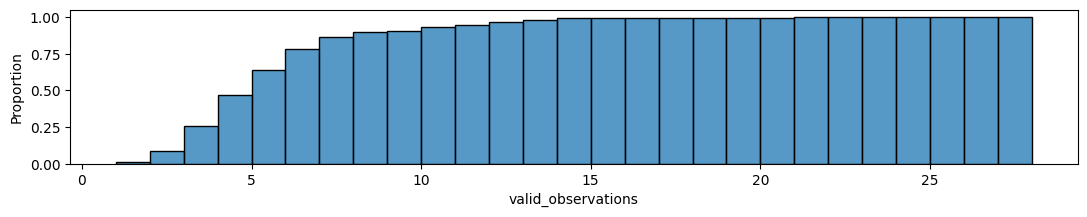

In [37]:
plt.figure(figsize=(13,2))
sns.histplot(df.valid_observations.astype(int), binwidth=1, cumulative=True, stat="proportion")

<Axes: >

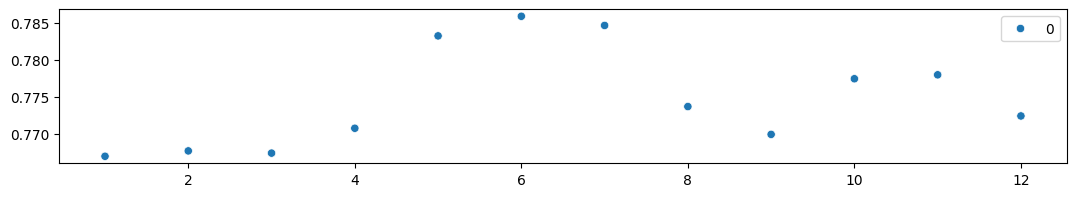

In [38]:
# Does the #valid-observation of a pixel matter? Yes.
df_ = df.loc[X_test.index]

min_valid_obs_to_f1 = {}
for n_valid_obs in sorted(df_.valid_observations.unique()):
    mask = df_.valid_observations >= n_valid_obs
    if mask.sum() < 1000:
        continue
    min_valid_obs_to_f1[n_valid_obs] = f1_score(y_test[mask], yhat_test[mask], average='macro', zero_division=0)

plt.figure(figsize=(13,2 ))
sns.scatterplot(pd.DataFrame.from_dict(min_valid_obs_to_f1, orient="index"))

In [39]:
# Only consider points with several passes
mask = df.valid_observations < 7
print(f"Discarded {mask.sum()}/{len(df)} ({mask.sum() / len(df) * 100:.2f}%) points")
df = df[~mask]

Discarded 77418/99473 (77.83%) points


In [40]:
# Split
features = ['blue', "green", "red", "rededge", "nir", "swir22", "tci", "ndvi", "gndvi", "ndwi"]
X = df[features]
y = df["ethz_map"] > 0.65

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y > 0.65)


yhat_train, yhat_test = train_test_lgbm(X_train, y_train, X_test, y_test);

[I 2026-06-11 17:18:14,782] A new study created in memory with name: no-name-2c10267a-c8f9-47c1-8792-0de484592d12


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-11 17:18:19,485] Trial 0 finished with value: 0.7826207722993186 and parameters: {'n_estimators': 466, 'learning_rate': 0.010033080955404106, 'max_depth': 5, 'num_leaves': 108, 'subsample': 0.8454034965392014, 'colsample_bytree': 0.9182675042609028, 'min_child_samples': 16}. Best is trial 0 with value: 0.7826207722993186.
[I 2026-06-11 17:18:23,014] Trial 1 finished with value: 0.7858642761633237 and parameters: {'n_estimators': 268, 'learning_rate': 0.025227282699499504, 'max_depth': 6, 'num_leaves': 87, 'subsample': 0.8251922432274487, 'colsample_bytree': 0.676314920389427, 'min_child_samples': 95}. Best is trial 1 with value: 0.7858642761633237.
[I 2026-06-11 17:18:26,177] Trial 2 finished with value: 0.7700259605909098 and parameters: {'n_estimators': 110, 'learning_rate': 0.16675245164164787, 'max_depth': 11, 'num_leaves': 224, 'subsample': 0.524625193440972, 'colsample_bytree': 0.9224632225510406, 'min_child_samples': 40}. Best is trial 1 with value: 0.7858642761633237

# Use neighbouring pixel val

In [43]:
df = df.drop(columns=["scene_classification_3x3_median"])

In [52]:
df["tci_3x3_median"] = 1.2 * (df["rededge_3x3_median"] - df["green_3x3_median"]) - 1.5 * (df["red_3x3_median"] - df["green_3x3_median"]) * np.sqrt(df["rededge_3x3_median"] / df["red_3x3_median"])
df["gndvi_3x3_median"] = (df["nir_3x3_median"] - df["green_3x3_median"]) / (df["nir_3x3_median"] + df["green_3x3_median"])
df["ndvi_3x3_median"] = (df["nir_3x3_median"] - df["red_3x3_median"]) / (df["nir_3x3_median"] + df["red_3x3_median"])
df["ndwi_3x3_median"] = (df["nir_3x3_median"] - df["swir22_3x3_median"]) / (df["nir_3x3_median"] + df["swir22_3x3_median"])

In [53]:
median_cols = [e for e in df.columns if e.endswith("median")]
df[median_cols].head(2)

/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,blue_3x3_median,green_3x3_median,red_3x3_median,rededge_3x3_median,nir_3x3_median,swir22_3x3_median,gndvi_3x3_median,ndwi_3x3_median,tci_3x3_median,ndvi_3x3_median
44503700,0.090210,0.098022,0.090210,0.113708,0.133301,0.094116,0.152466,0.172363,0.031982,0.192749
59668718,0.070618,0.098022,0.094116,0.133301,0.254883,0.133301,0.444336,0.313232,0.049316,0.460449


In [55]:
# Split
features = ['blue', "green", "red", "rededge", "nir", "swir22", "tci", "ndvi", "gndvi", "ndwi"] + median_cols
X = df[features]
y = df["ethz_map"] > 0.65

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y > 0.65)


yhat_train, yhat_test = train_test_lgbm(X_train, y_train, X_test, y_test, n_trials=50);

[I 2026-06-11 17:22:01,489] A new study created in memory with name: no-name-1506b0bf-631a-46de-999a-69368cf17e43


Starting Optuna hyperparameter optimization...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-11 17:22:04,761] Trial 0 finished with value: 0.7957475305822234 and parameters: {'n_estimators': 406, 'learning_rate': 0.015825067822680665, 'max_depth': 6, 'num_leaves': 45, 'subsample': 0.6371944304539785, 'colsample_bytree': 0.9905483472577477, 'min_child_samples': 73}. Best is trial 0 with value: 0.7957475305822234.
[I 2026-06-11 17:22:08,884] Trial 1 finished with value: 0.7924671165024162 and parameters: {'n_estimators': 295, 'learning_rate': 0.011620299066545024, 'max_depth': 6, 'num_leaves': 184, 'subsample': 0.9499249612509467, 'colsample_bytree': 0.9017075887478012, 'min_child_samples': 72}. Best is trial 0 with value: 0.7957475305822234.
[I 2026-06-11 17:22:09,879] Trial 2 finished with value: 0.7937368345605249 and parameters: {'n_estimators': 232, 'learning_rate': 0.11696070984624256, 'max_depth': 3, 'num_leaves': 128, 'subsample': 0.850332610451715, 'colsample_bytree': 0.5756958152454702, 'min_child_samples': 64}. Best is trial 0 with value: 0.7957475305822234

In [ ]:
3. The Robust Estimation (The Rogan-Gladen Estimator)